# 06 — Supply-demand equilibrium and incidence

Reproduces **Figures 5-6** of the paper (market equilibrium with comparative statics) and builds the passthrough-elasticity table from §14.

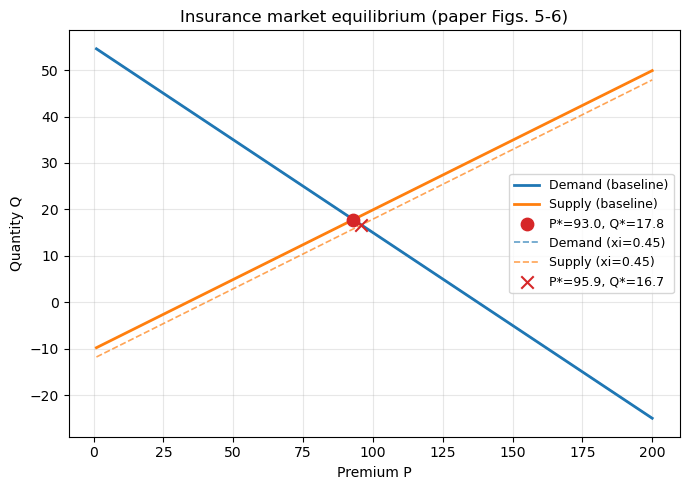

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from dcrisk.econ.market import equilibrium, plot_equilibrium
from dcrisk.econ.incidence import passthrough_table
from dcrisk.econ.operator import plot_operator_cost, find_optimum

# --- equilibrium under baseline + tail-thickening shift ---
fig, ax = plt.subplots(figsize=(7, 5))
plot_equilibrium(lam=1.0, xi=0.20, theta=1.5, theta_op=1.0, shifts={'xi': 0.45}, ax=ax)
fig.tight_layout()

In [2]:
# --- passthrough elasticity table swept over xi ---
df = passthrough_table({'xi': [0.10, 0.20, 0.35, 0.50, 0.70]})
df.round(3)

,swept,value,P*,Q*,eps_demand,eps_supply,share_operator,share_insurer
0,xi,0.10,91.857,18.257,-2.013,1.509,0.429,0.571
1,xi,0.20,93.000,17.800,-2.090,1.567,0.429,0.571
2,xi,0.35,94.714,17.114,-2.214,1.660,0.429,0.571
3,xi,0.50,96.429,16.429,-2.348,1.761,0.429,0.571
4,xi,0.70,98.714,15.514,-2.545,1.909,0.429,0.571


K* = 8.682, C(K*) = 7.517


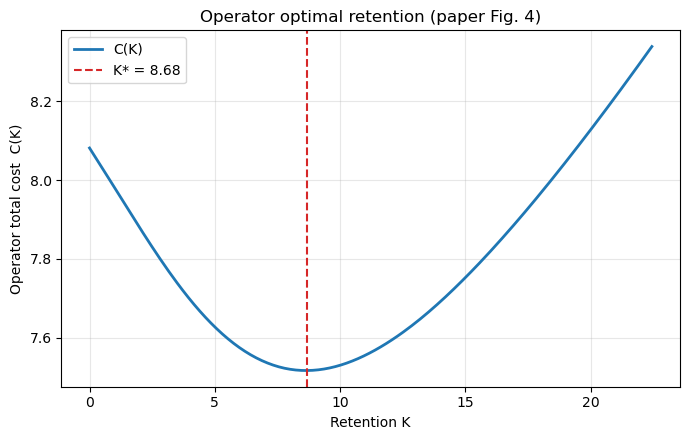

In [3]:
# --- operator cost as a sanity overlay (Fig. 4) ---
rng = np.random.default_rng(0)
S = rng.gamma(shape=2.0, scale=3.0, size=20_000)  # placeholder aggregate sample
fig, ax = plt.subplots(figsize=(7, 4.5))
plot_operator_cost(r=0.10, lambda_K=1.20, xi_K=0.20, S_samples=S, ax=ax)
K_star, C_star = find_optimum(0.10, 1.20, 0.20, S)
print(f'K* = {K_star:.3f}, C(K*) = {C_star:.3f}')
fig.tight_layout()